Cell 1: Imports & Seed

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow: 2.13.0


In [2]:
TRAIN_DIR = "../dataset/train"
VAL_DIR   = "../dataset/validation"
TEST_DIR  = "../dataset/test"
IMG_SIZE = 224


Cell 3: Custom Preprocessing (SAME as VGG16)

In [3]:
import cv2

def custom_preprocessing(img):
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3,3), 0)

    gray = gray.astype(np.float32) / 255.0

    out = np.stack([gray, gray, gray], axis=-1)
    return out


In [4]:
BATCH_SIZE = 8  # keep same as VGG16

train_gen = ImageDataGenerator(
    preprocessing_function=custom_preprocessing,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True
)

val_gen  = ImageDataGenerator(preprocessing_function=custom_preprocessing)
test_gen = ImageDataGenerator(preprocessing_function=custom_preprocessing)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)


Found 1843 images belonging to 2 classes.
Found 235 images belonging to 2 classes.
Found 437 images belonging to 2 classes.


In [5]:
class_weights = {0: 0.8477460901563938, 1: 1.218915343915344}
class_weights


{0: 0.8477460901563938, 1: 1.218915343915344}

In [6]:
base = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

base.trainable = False  # freeze all layers first

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base.input, outputs=output)
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [8]:
os.makedirs("../models", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        "../models/resnet50_best.h5",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]


In [9]:
EPOCHS = 25

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/25
231/231 [==============================] - ETA: 0s - loss: 0.7425 - accuracy: 0.5111 - precision: 0.4264 - recall: 0.5556 - auc: 0.5126
Epoch 1: val_auc improved from -inf to 0.52919, saving model to ../models\resnet50_best.h5


c:\Users\admin\Desktop\Brain_Stroke_Project\stroke_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


231/231 [==============================] - 148s 618ms/step - loss: 0.7425 - accuracy: 0.5111 - precision: 0.4264 - recall: 0.5556 - auc: 0.5126 - val_loss: 0.6611 - val_accuracy: 0.6681 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5292 - lr: 1.0000e-04
Epoch 2/25
231/231 [==============================] - ETA: 0s - loss: 0.7123 - accuracy: 0.4856 - precision: 0.4006 - recall: 0.5119 - auc: 0.4882
Epoch 2: val_auc did not improve from 0.52919
231/231 [==============================] - 175s 756ms/step - loss: 0.7123 - accuracy: 0.4856 - precision: 0.4006 - recall: 0.5119 - auc: 0.4882 - val_loss: 0.6701 - val_accuracy: 0.6681 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5216 - lr: 1.0000e-04
Epoch 3/25
231/231 [==============================] - ETA: 0s - loss: 0.7038 - accuracy: 0.4780 - precision: 0.3957 - recall: 0.5172 - auc: 0.4869
Epoch 3: val_auc did not improve from 0.52919
231/231 [==============================] - 267s 1s/step - loss: 0.

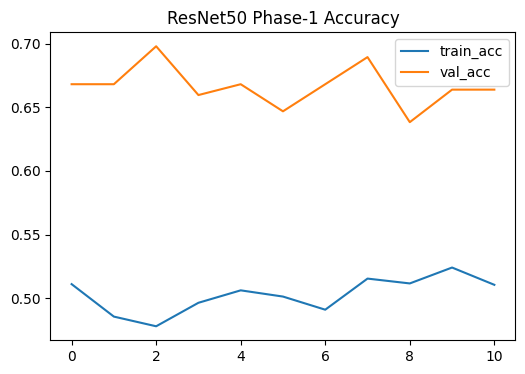

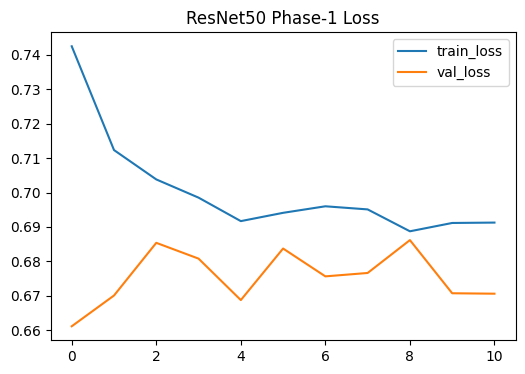

In [10]:
def plot_history(hist, title):
    h = hist.history
    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="train_acc")
    plt.plot(h["val_accuracy"], label="val_acc")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

plot_history(history1, "ResNet50 Phase-1")


In [11]:
test_metrics = model.evaluate(test_data, verbose=1)
print(dict(zip(model.metrics_names, test_metrics)))


55/55 [==============================] - 45s 825ms/step - loss: 0.6665 - accuracy: 0.7025 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.5815
{'loss': 0.6664763689041138, 'accuracy': 0.7025171518325806, 'precision': 0.0, 'recall': 0.0, 'auc': 0.5815334320068359}


Step 1: Unfreeze ONLY the last ResNet block

In [12]:
# Unfreeze only the last ResNet block (conv5_x)
for layer in base.layers:
    layer.trainable = False

for layer in base.layers:
    if layer.name.startswith("conv5"):
        layer.trainable = True

# Check trainable layers
trainable_count = sum([layer.trainable for layer in model.layers])
print("Trainable layers:", trainable_count)


Trainable layers: 38


In [13]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very small LR
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [14]:
FINE_TUNE_EPOCHS = 8  # do NOT exceed 10 on CPU

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/8
231/231 [==============================] - ETA: 0s - loss: 0.6918 - accuracy: 0.5193 - precision: 0.4435 - recall: 0.6746 - auc: 0.5635
Epoch 1: val_auc improved from 0.62739 to 0.68063, saving model to ../models\resnet50_best.h5
231/231 [==============================] - 285s 1s/step - loss: 0.6918 - accuracy: 0.5193 - precision: 0.4435 - recall: 0.6746 - auc: 0.5635 - val_loss: 0.6608 - val_accuracy: 0.6426 - val_precision: 0.4634 - val_recall: 0.4872 - val_auc: 0.6806 - lr: 1.0000e-05
Epoch 2/8
231/231 [==============================] - ETA: 0s - loss: 0.6560 - accuracy: 0.6023 - precision: 0.5121 - recall: 0.6455 - auc: 0.6555
Epoch 2: val_auc improved from 0.68063 to 0.80692, saving model to ../models\resnet50_best.h5
231/231 [==============================] - 273s 1s/step - loss: 0.6560 - accuracy: 0.6023 - precision: 0.5121 - recall: 0.6455 - auc: 0.6555 - val_loss: 0.5715 - val_accuracy: 0.7660 - val_precision: 0.6716 - val_recall: 0.5769 - val_auc: 0.8069 - lr: 1.000

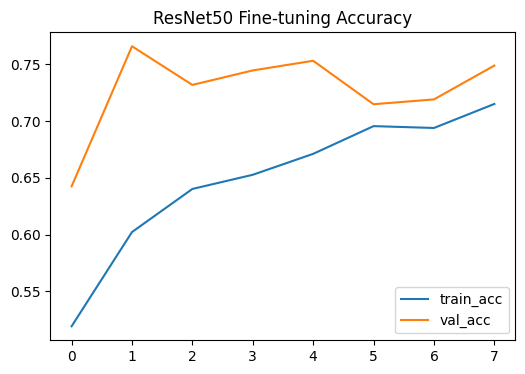

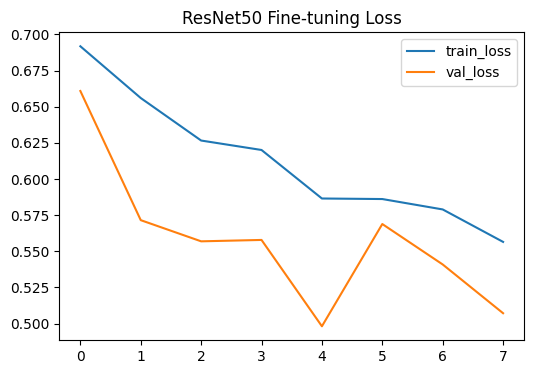

In [15]:
plot_history(history2, "ResNet50 Fine-tuning")


In [16]:
test_metrics_ft = model.evaluate(test_data, verbose=1)
print(dict(zip(model.metrics_names, test_metrics_ft)))


55/55 [==============================] - 20s 367ms/step - loss: 0.5001 - accuracy: 0.7826 - precision: 0.5936 - recall: 0.8538 - auc: 0.8650
{'loss': 0.5001367330551147, 'accuracy': 0.782608687877655, 'precision': 0.5935828685760498, 'recall': 0.8538461327552795, 'auc': 0.8650463819503784}


In [17]:
import numpy as np

# Reset generator to avoid index issues
test_data.reset()

# Predict probabilities
y_prob = model.predict(test_data, verbose=1)

# Convert probabilities to class labels (threshold = 0.5)
y_pred = (y_prob >= 0.5).astype(int).ravel()

# Ground truth labels
y_true = test_data.classes

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)


55/55 [==============================] - 30s 527ms/step
y_true shape: (437,)
y_pred shape: (437,)


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Normal", "Stroke"]))


Confusion Matrix:
 [[231  76]
 [ 19 111]]

Classification Report:

              precision    recall  f1-score   support

      Normal       0.92      0.75      0.83       307
      Stroke       0.59      0.85      0.70       130

    accuracy                           0.78       437
   macro avg       0.76      0.80      0.76       437
weighted avg       0.83      0.78      0.79       437



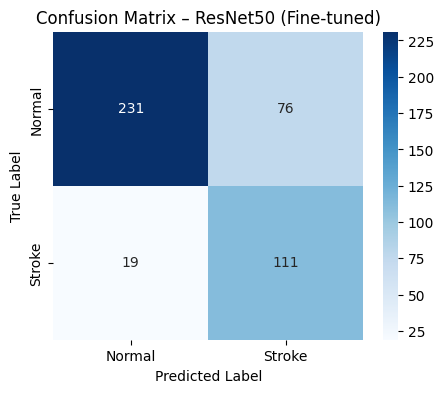

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Stroke"],
    yticklabels=["Normal", "Stroke"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – ResNet50 (Fine-tuned)")
plt.show()


In [20]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

print("ROC–AUC:", roc_auc)


ROC–AUC: 0.8646203958907542


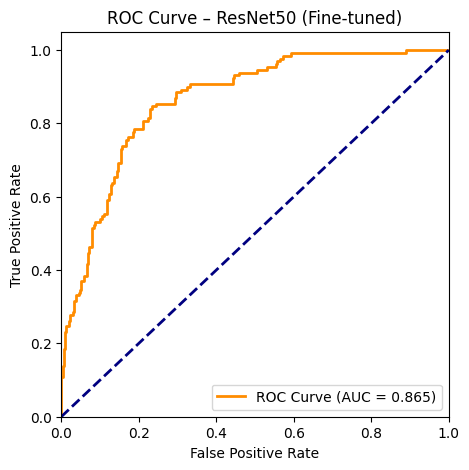

In [21]:
plt.figure(figsize=(5,5))

plt.plot(
    fpr, tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ResNet50 (Fine-tuned)")
plt.legend(loc="lower right")
plt.show()
